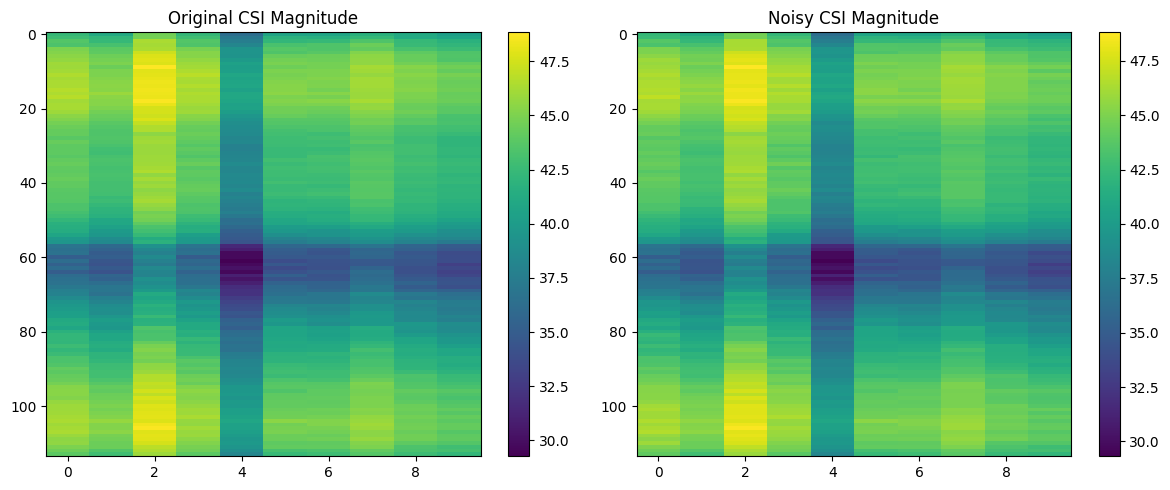

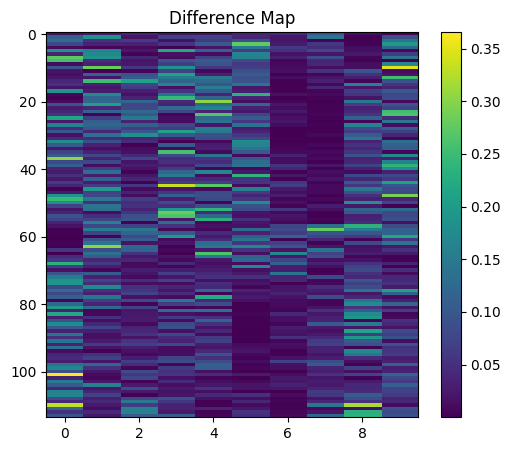

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import sys
import os

sys.path.append(os.path.abspath(".."))
from Utils.random_noise import RandomNoisePerturbation

# ==========================================================
# 1. CSI 로드
# ==========================================================

sample_path = "../frame001.mat"

mat_data = loadmat(sample_path)

amp = np.nan_to_num(mat_data["CSIamp"])
phase = np.nan_to_num(mat_data["CSIphase"])

original = amp * np.exp(1j * phase)

# ==========================================================
# 2. Perturbation
# ==========================================================

perturb = RandomNoisePerturbation(
    sigma=0.13,
    alpha=0.1
)

noisy = perturb(original)

# ==========================================================
# 3. Visualization
# ==========================================================

original_mag = np.abs(original)
noisy_mag = np.abs(noisy)

plt.figure(figsize=(12, 5))

# ==========================================================
# Original
# ==========================================================

plt.subplot(1, 2, 1)

plt.imshow(
    original_mag[0],
    aspect='auto'
)

plt.title("Original CSI Magnitude")

plt.colorbar()

# ==========================================================
# Noisy
# ==========================================================

plt.subplot(1, 2, 2)

plt.imshow(
    noisy_mag[0],
    aspect='auto'
)

plt.title("Noisy CSI Magnitude")

plt.colorbar()

plt.tight_layout()

plt.show()

diff_mag = np.abs(noisy_mag - original_mag)

plt.figure(figsize=(6,5))

plt.imshow(
    diff_mag[0],
    aspect='auto'
)

plt.title("Difference Map")

plt.colorbar()

plt.show()

# 실험 요약본 
※ 기존에는 CSI 데이터를 전부 미리 tensor로 만든 뒤 학습했기 때문에,
noise를 동적으로 추가할 수 없었다.

※ 이를 해결하기 위해 MMFiDataset 구조로 변경하였고,
데이터를 불러오는 __getitem__() 단계에서
실시간으로 noise를 추가하도록 수정하였다.

※ RandomNoisePerturbation 클래스를 만들어
Gaussian noise와 phase noise를 CSI에 적용할 수 있도록 구성하였다.

※ 이제는 Dataset 생성 시 perturbation만 바꿔서
clean / random noise / realistic interference 실험을
같은 구조에서 재사용할 수 있게 되었다.

### 코드 패치노트
※ 기존 실험에서는 모든 CSI 데이터를 한 번에 tensor로 변환한 뒤
TensorDataset 기반으로 학습을 수행하였다.
이 구조에서는 noise augmentation을 실시간으로 적용하기 어렵다는 문제가 있었다.

※ 이를 해결하기 위해 데이터 로딩 구조를 MMFiDataset 기반으로 변경하였다.
Dataset 내부의 __getitem__() 단계에서 CSI를 직접 불러오도록 수정하였으며,
이 과정에서 perturbation module을 연결할 수 있도록 인터페이스를 추가하였다.

※ RandomNoisePerturbation 클래스를 별도로 구현하여
Gaussian amplitude noise와 phase perturbation을 CSI에 적용할 수 있도록 구성하였다.

※ 학습 시에는 perturbation=RandomNoisePerturbation(...) 형태로
Dataset에 noise module을 전달하여,
매 iteration마다 새로운 random noise가 CSI에 실시간 적용되도록 구성하였다.

※ 기존 TensorDataset 구조에서는 동일한 noise가 반복적으로 사용되는
offline augmentation 형태였으나,
현재 구조는 __getitem__()에서 noise를 동적으로 생성하는
online augmentation 방식으로 변경되었다.

※ 또한 clean / noisy / realistic interference 환경을 동일한 Dataset 구조에서
재사용할 수 있도록 perturbation interface 기반 구조로 통합하였다.
이를 통해 perturbation=None,
perturbation=RandomNoisePerturbation(),
perturbation=SionnaPerturbation()
형태로 실험 환경을 쉽게 교체할 수 있도록 설계하였다.

※ CSI visualization을 통해 perturbation 적용 전후의 magnitude 및 difference map을 비교하였으며,
noise가 CSI 구조를 완전히 파괴하지 않으면서도
feature-level distribution shift를 유도함을 확인하였다.